In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

COMPARISON OF LOCAL FEATURE DESCRIPTORS

FEATURE EXTRACTION RESULTS:
----------------------------------------


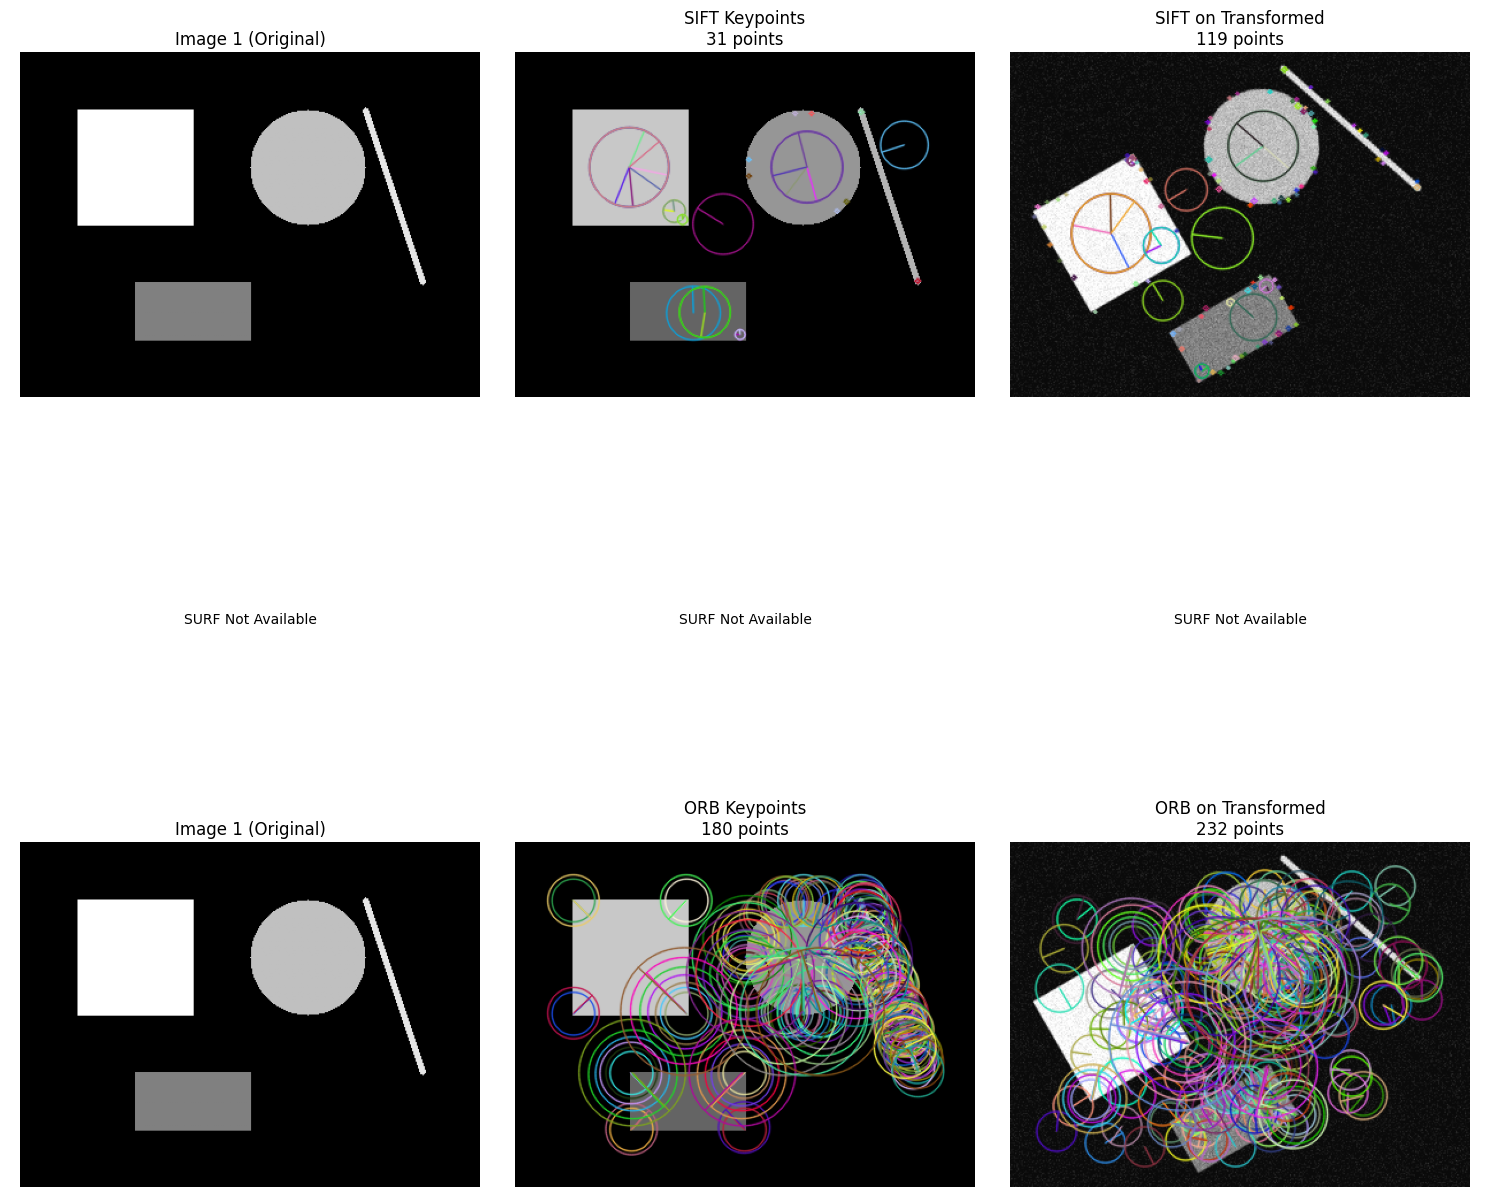


FEATURE DETECTOR COMPARISON:
Method     Image1 KP    Image2 KP    Descriptor Dim  Type       Repeatability  
--------------------------------------------------------------------------------
SIFT       31           119          128             Float32    383.9          %
ORB        180          232          32              Binary     128.9          %

FEATURE MATCHING DEMONSTRATION:
----------------------------------------

Matching Results:
SIFT: 16 good matches found
  Average distance: 118.90
  Min distance: 39.89
  Max distance: 345.40
ORB: 28 good matches found
  Average distance: 62.93
  Min distance: 19.00
  Max distance: 88.00


In [2]:
def latihan_1():
    print("COMPARISON OF LOCAL FEATURE DESCRIPTORS")
    print("=" * 50)
    
    # Buat citra test dengan transformasi
    def create_test_images():
        # Citra dasar dengan pattern yang jelas
        img1 = np.zeros((300, 400), dtype=np.uint8)
        
        # Tambahkan shapes dengan corner features
        cv2.rectangle(img1, (50, 50), (150, 150), 200, -1)  # Square
        cv2.circle(img1, (250, 100), 50, 150, -1)           # Circle
        cv2.rectangle(img1, (100, 200), (200, 250), 100, -1) # Rectangle
        cv2.line(img1, (300, 50), (350, 200), 180, 3)       # Diagonal line
        
        # Citra kedua dengan transformasi
        # 1. Rotation
        M_rotate = cv2.getRotationMatrix2D((200, 150), 30, 1.0)
        img2 = cv2.warpAffine(img1, M_rotate, (400, 300))
        
        # 2. Scale
        img2 = cv2.resize(img2, None, fx=0.9, fy=0.9)
        
        # 3. Add noise
        noise = np.random.normal(0, 10, img2.shape)
        img2 = np.clip(img2.astype(float) + noise, 0, 255).astype(np.uint8)
        
        # 4. Brightness change
        img2 = cv2.convertScaleAbs(img2, alpha=1.2, beta=10)
        
        return img1, img2
    
    img1, img2 = create_test_images()
    
    # Inisialisasi feature detectors
    try:
        # SIFT
        sift = cv2.SIFT_create()
        
        # SURF (jika tersedia)
        try:
            surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
            surf_status = "Available"
        except:
            surf = None
            surf_status = "Not Available"
        
        # ORB
        orb = cv2.ORB_create(nfeatures=500)
        
    except Exception as e:
        print(f"Error initializing feature detectors: {e}")
        return
    
    # Function untuk ekstraksi dan visualisasi features
    def extract_and_display_features(detector, img, detector_name):
        if detector is None:
            return None, None, None
        
        # Detect keypoints dan compute descriptors
        keypoints, descriptors = detector.detectAndCompute(img, None)
        
        # Draw keypoints
        img_with_kp = cv2.drawKeypoints(img, keypoints, None, 
                                       flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        
        return keypoints, descriptors, img_with_kp
    
    # Ekstraksi features dari kedua citra
    print("\nFEATURE EXTRACTION RESULTS:")
    print("-" * 40)
    
    results = {}
    
    # SIFT
    kp1_sift, desc1_sift, img1_sift = extract_and_display_features(sift, img1, "SIFT")
    kp2_sift, desc2_sift, img2_sift = extract_and_display_features(sift, img2, "SIFT")
    if kp1_sift is not None:
        results['SIFT'] = {
            'img1_kp': len(kp1_sift),
            'img2_kp': len(kp2_sift),
            'desc_dim': desc1_sift.shape[1] if desc1_sift is not None else 0,
            'desc_type': 'Float32'
        }
    
    # SURF
    if surf is not None:
        kp1_surf, desc1_surf, img1_surf = extract_and_display_features(surf, img1, "SURF")
        kp2_surf, desc2_surf, img2_surf = extract_and_display_features(surf, img2, "SURF")
        if kp1_surf is not None:
            results['SURF'] = {
                'img1_kp': len(kp1_surf),
                'img2_kp': len(kp2_surf),
                'desc_dim': desc1_surf.shape[1] if desc1_surf is not None else 0,
                'desc_type': 'Float32'
            }
    
    # ORB
    kp1_orb, desc1_orb, img1_orb = extract_and_display_features(orb, img1, "ORB")
    kp2_orb, desc2_orb, img2_orb = extract_and_display_features(orb, img2, "ORB")
    if kp1_orb is not None:
        results['ORB'] = {
            'img1_kp': len(kp1_orb),
            'img2_kp': len(kp2_orb),
            'desc_dim': desc1_orb.shape[1] if desc1_orb is not None else 0,
            'desc_type': 'Binary'
        }
    
    # Visualisasi results
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Row 1: SIFT
    if 'SIFT' in results:
        axes[0, 0].imshow(img1, cmap='gray')
        axes[0, 0].set_title('Image 1 (Original)')
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(cv2.cvtColor(img1_sift, cv2.COLOR_BGR2RGB))
        axes[0, 1].set_title(f'SIFT Keypoints\n{results["SIFT"]["img1_kp"]} points')
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(cv2.cvtColor(img2_sift, cv2.COLOR_BGR2RGB))
        axes[0, 2].set_title(f'SIFT on Transformed\n{results["SIFT"]["img2_kp"]} points')
        axes[0, 2].axis('off')
    else:
        for i in range(3):
            axes[0, i].text(0.5, 0.5, 'SIFT Not Available', 
                          ha='center', va='center', transform=axes[0, i].transAxes)
            axes[0, i].axis('off')
    
    # Row 2: SURF
    if 'SURF' in results:
        axes[1, 0].imshow(img1, cmap='gray')
        axes[1, 0].set_title('Image 1 (Original)')
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(cv2.cvtColor(img1_surf, cv2.COLOR_BGR2RGB))
        axes[1, 1].set_title(f'SURF Keypoints\n{results["SURF"]["img1_kp"]} points')
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(cv2.cvtColor(img2_surf, cv2.COLOR_BGR2RGB))
        axes[1, 2].set_title(f'SURF on Transformed\n{results["SURF"]["img2_kp"]} points')
        axes[1, 2].axis('off')
    else:
        for i in range(3):
            axes[1, i].text(0.5, 0.5, 'SURF Not Available', 
                          ha='center', va='center', transform=axes[1, i].transAxes)
            axes[1, i].axis('off')
    
    # Row 3: ORB
    if 'ORB' in results:
        axes[2, 0].imshow(img1, cmap='gray')
        axes[2, 0].set_title('Image 1 (Original)')
        axes[2, 0].axis('off')
        
        axes[2, 1].imshow(cv2.cvtColor(img1_orb, cv2.COLOR_BGR2RGB))
        axes[2, 1].set_title(f'ORB Keypoints\n{results["ORB"]["img1_kp"]} points')
        axes[2, 1].axis('off')
        
        axes[2, 2].imshow(cv2.cvtColor(img2_orb, cv2.COLOR_BGR2RGB))
        axes[2, 2].set_title(f'ORB on Transformed\n{results["ORB"]["img2_kp"]} points')
        axes[2, 2].axis('off')
    else:
        for i in range(3):
            axes[2, i].text(0.5, 0.5, 'ORB Not Available', 
                          ha='center', va='center', transform=axes[2, i].transAxes)
            axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Display comparison table
    print("\nFEATURE DETECTOR COMPARISON:")
    print("=" * 80)
    print(f"{'Method':<10} {'Image1 KP':<12} {'Image2 KP':<12} {'Descriptor Dim':<15} {'Type':<10} {'Repeatability':<15}")
    print("-" * 80)
    
    for method, data in results.items():
        repeatability = data['img2_kp'] / data['img1_kp'] * 100 if data['img1_kp'] > 0 else 0
        print(f"{method:<10} {data['img1_kp']:<12} {data['img2_kp']:<12} "
              f"{data['desc_dim']:<15} {data['desc_type']:<10} {repeatability:<15.1f}%")
    
    # Feature matching demonstration
    print("\nFEATURE MATCHING DEMONSTRATION:")
    print("-" * 40)
    
    def demonstrate_feature_matching(desc1, desc2, kp1, kp2, method_name, matcher_type='bf'):
        if desc1 is None or desc2 is None or len(kp1) == 0 or len(kp2) == 0:
            print(f"{method_name}: No features to match")
            return None
        
        # Create matcher based on descriptor type
        if method_name == 'ORB':
            # Binary descriptor → Hamming distance
            matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        else:
            # Floating point descriptor → L2 distance
            matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
        
        # Match descriptors
        matches = matcher.match(desc1, desc2)
        
        # Sort matches by distance
        matches = sorted(matches, key=lambda x: x.distance)
        
        # Take top matches
        good_matches = matches[:50]
        
        print(f"{method_name}: {len(good_matches)} good matches found")
        print(f"  Average distance: {np.mean([m.distance for m in good_matches]):.2f}")
        print(f"  Min distance: {min([m.distance for m in good_matches]):.2f}")
        print(f"  Max distance: {max([m.distance for m in good_matches]):.2f}")
        
        return good_matches
    
    # Match features untuk setiap metode
    print("\nMatching Results:")
    if 'SIFT' in results and kp1_sift is not None and kp2_sift is not None:
        matches_sift = demonstrate_feature_matching(desc1_sift, desc2_sift, kp1_sift, kp2_sift, "SIFT")
    
    if 'SURF' in results and kp1_surf is not None and kp2_surf is not None:
        matches_surf = demonstrate_feature_matching(desc1_surf, desc2_surf, kp1_surf, kp2_surf, "SURF")
    
    if 'ORB' in results and kp1_orb is not None and kp2_orb is not None:
        matches_orb = demonstrate_feature_matching(desc1_orb, desc2_orb, kp1_orb, kp2_orb, "ORB")
    
    return results

# Jalankan latihan 1
feature_results = latihan_1()